# Non-Linear SVM - Email Spam Classifier


In this section, we'll build a non-linear SVM classifier to classify emails and compare the performance with the linear SVM model.

In this section, we will build a non-linear model (using non-linear kernels) and then find the optimal hyperparameters (the choice of `kernel`, `C`, `gamma`).

In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

**Loading Data**

In [2]:
email_rec = pd.read_csv("Spam.csv")

#### Data Split and Scaling

We must first split to avoid any data leakage

In [3]:
# splitting into X and y
X = email_rec.drop("spam", axis=1)
y = email_rec["spam"].astype(int)

In [4]:
# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4, stratify=y)

In [5]:
# scaling the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [6]:
# confirm that splitting also has similar distribution of spam and ham emails
print(y_train.mean())
print(y_test.mean())

0.3940993788819876
0.3939174511223751


## Model Building

In [7]:
# using rbf kernel, C=1, default value of gamma

model = SVC(C = 1, kernel='rbf')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Model Evaluation Metrics

In [8]:
# confusion matrix
confusion_matrix(y_true=y_test, y_pred=y_pred)

array([[805,  32],
       [ 74, 470]])

In [9]:
# accuracy
print("accuracy", metrics.accuracy_score(y_test, y_pred))

# precision
print("precision", metrics.precision_score(y_test, y_pred))

# recall/sensitivity
print("recall", metrics.recall_score(y_test, y_pred))

accuracy 0.9232440260680667
precision 0.9362549800796812
recall 0.8639705882352942


## Hyperparameter Tuning 

Now, we have multiple hyperparameters to optimise - 
- The choice of kernel (*linear*, *rbf* etc.)
- `C`
- `gamma`

We'll use the `GridSearchCV()` method to tune the hyperparameters. 

## Grid Search to Find Optimal Hyperparameters

Let's first use the RBF kernel to find the optimal `C` and `gamma` (we can consider the kernel as a hyperparameter as well, though training the model will take an exorbitant amount of time). 

In [10]:
# creating a KFold object with 5 splits 
folds = KFold(n_splits = 5, shuffle = True, random_state = 4)

# specify range of hyperparameters
# Set the parameters by cross-validation
hyper_params = [ {'gamma': [1e-2, 1e-3, 1e-4],
                     'C': [1, 10, 100, 1000]}]


# specify model
model = SVC(kernel="rbf")

# set up GridSearchCV()
model_cv = GridSearchCV(estimator = model, 
                        param_grid = hyper_params, 
                        scoring= 'accuracy', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True)      

# fit the model
model_cv.fit(X_train, y_train)                  


Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,SVC()
,param_grid,"[{'C': [1, 10, ...], 'gamma': [0.01, 0.001, ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,10


In [11]:
# cv results
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.064079,0.006553,0.040354,0.012910,1,0.0100,"{'C': 1, 'gamma': 0.01}",0.948758,0.940994,0.922360,...,0.929814,0.012857,6,0.940217,0.941382,0.946040,0.947981,0.947981,0.944720,0.003299
1,0.088609,0.009771,0.047714,0.002518,1,0.0010,"{'C': 1, 'gamma': 0.001}",0.920807,0.911491,0.886646,...,0.899689,0.013944,10,0.900233,0.902562,0.905668,0.906444,0.904503,0.903882,0.002245
2,0.131423,0.005739,0.076186,0.003528,1,0.0001,"{'C': 1, 'gamma': 0.0001}",0.774845,0.826087,0.777950,...,0.790373,0.018762,12,0.788432,0.788820,0.800854,0.797360,0.792702,0.793634,0.004840
3,0.052585,0.002740,0.022668,0.001486,10,0.0100,"{'C': 10, 'gamma': 0.01}",0.951863,0.953416,0.936335,...,0.939752,0.010954,1,0.961957,0.963121,0.966615,0.968168,0.967780,0.965528,0.002521
4,0.066982,0.017980,0.030730,0.002904,10,0.0010,"{'C': 10, 'gamma': 0.001}",0.947205,0.936335,0.919255,...,0.927640,0.012052,7,0.927795,0.935171,0.938665,0.939829,0.938665,0.936025,0.004402
5,0.077920,0.003213,0.044091,0.001839,10,0.0001,"{'C': 10, 'gamma': 0.0001}",0.919255,0.905280,0.881988,...,0.896273,0.014143,11,0.893634,0.898680,0.902174,0.904115,0.901786,0.900078,0.003663
6,0.074954,0.004630,0.019405,0.000388,100,0.0100,"{'C': 100, 'gamma': 0.01}",0.933230,0.950311,0.909938,...,0.930745,0.012977,5,0.979037,0.978261,0.982143,0.982143,0.982531,0.980823,0.001797
7,0.065010,0.007902,0.023966,0.004861,100,0.0010,"{'C': 100, 'gamma': 0.001}",0.948758,0.950311,0.927019,...,0.935093,0.011842,3,0.945652,0.944488,0.949146,0.952252,0.954193,0.949146,0.003715
8,0.064754,0.005109,0.033028,0.003780,100,0.0001,"{'C': 100, 'gamma': 0.0001}",0.944099,0.931677,0.905280,...,0.922671,0.013622,9,0.921196,0.929348,0.930901,0.936724,0.933230,0.930280,0.005177
9,0.140852,0.015053,0.020933,0.001062,1000,0.0100,"{'C': 1000, 'gamma': 0.01}",0.925466,0.937888,0.902174,...,0.922981,0.013198,8,0.991071,0.989907,0.993012,0.994953,0.992624,0.992314,0.001726


Next, we will plot 3 graphs, each showing the variation of scores over chosen values of `C`, for a `gamma` value

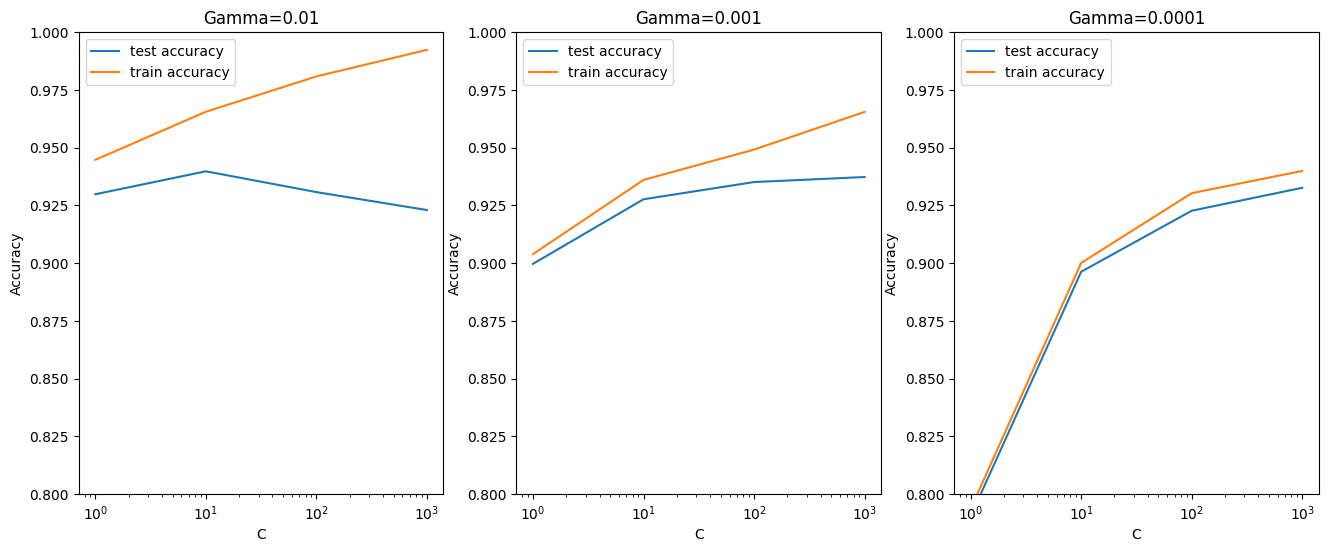

In [12]:
# converting C to numeric type for plotting on x-axis
cv_results['param_C'] = cv_results['param_C'].astype('int')

# # plotting
plt.figure(figsize=(16,6))

# subplot 1/3
plt.subplot(131)
gamma_01 = cv_results[cv_results['param_gamma']==0.01]

plt.plot(gamma_01["param_C"], gamma_01["mean_test_score"])
plt.plot(gamma_01["param_C"], gamma_01["mean_train_score"])
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title("Gamma=0.01")
plt.ylim([0.80, 1])
plt.legend(['test accuracy', 'train accuracy'], loc='upper left')
plt.xscale('log')

# subplot 2/3
plt.subplot(132)
gamma_001 = cv_results[cv_results['param_gamma']==0.001]

plt.plot(gamma_001["param_C"], gamma_001["mean_test_score"])
plt.plot(gamma_001["param_C"], gamma_001["mean_train_score"])
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title("Gamma=0.001")
plt.ylim([0.80, 1])
plt.legend(['test accuracy', 'train accuracy'], loc='upper left')
plt.xscale('log')


# subplot 3/3
plt.subplot(133)
gamma_0001 = cv_results[cv_results['param_gamma']==0.0001]

plt.plot(gamma_0001["param_C"], gamma_0001["mean_test_score"])
plt.plot(gamma_0001["param_C"], gamma_0001["mean_train_score"])
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title("Gamma=0.0001")
plt.ylim([0.80, 1])
plt.legend(['test accuracy', 'train accuracy'], loc='upper left')
plt.xscale('log')


This plot reveals some interesting insights:
- **High values of gamma** lead to **overfitting** (especially at high values of C); note that the training accuracy at `gamma=0.01` and `C=1000` reaches almost 99% 
- The **training score increases with higher gamma**, though the **test scores are comparable** (at sufficiently high cost, i.e. `C > 10`)
- The least amount of overfitting (i.e. difference between train and test accuracy) occurs at low gamma, i.e. a quite *simple non-linear model*


In [13]:
# printing the optimal accuracy score and hyperparameters
best_score = model_cv.best_score_
best_hyperparams = model_cv.best_params_

print("The best test score is {0} corresponding to hyperparameters {1}".format(best_score, best_hyperparams))

The best test score is 0.939751552795031 corresponding to hyperparameters {'C': 10, 'gamma': 0.01}


Although the grid search identifies (`gamma=0.01`, `C=10`) as the combination with the highest cross-validated accuracy (~0.9398), the improvement over lower-gamma models is marginal. From the validation curves, increasing gamma makes the decision boundary more flexible and more sensitive to local variations in the data, which increases model complexity.

However, a much smoother (and therefore simpler) model with `gamma=0.0001` achieves comparable test accuracy (~0.925–0.935) once `C` is increased. This shows the standard SVM trade-off:
- higher gamma → more non-linear, higher model complexity, moderate C  
- lower gamma → smoother, simpler boundary, requires higher C to achieve similar accuracy  

Given that the accuracy gain at `gamma=0.01` is modest, we may reasonably prefer the simpler model (`gamma=0.0001`, `C≈100`), as it offers nearly the same predictive performance with lower complexity and potentially better generalisation stability.


### Building and Evaluating the Final Model

Let's now build and evaluate the final model, i.e. the model with highest test accuracy.

In [14]:
# specify optimal hyperparameters
best_params = {"C": 100, "gamma": 0.0001, "kernel":"rbf"}

# model
model = SVC(C=100, gamma=0.0001, kernel="rbf")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# metrics
print(metrics.confusion_matrix(y_test, y_pred), "\n")
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Sensitivity/Recall:", metrics.recall_score(y_test, y_pred))

[[801  36]
 [ 82 462]] 

Accuracy: 0.9145546705286025
Precision: 0.927710843373494
Sensitivity/Recall: 0.8492647058823529


## Conclusion

The accuracy achieved using a non-linear kernel is comparable to that of a linear one. Thus, it turns out that for this problem, **you do not really need a non-linear kernel**.